# UMAP Label Transfer Demo

Demonstrates `UMAPLabelTransfer` for four combinations:

| Cell | Cell type | UMAP mode |
|------|-----------|------------|
| 1 | EXC | unsupervised |
| 2 | EXC | supervised   |
| 3 | INH | unsupervised |
| 4 | INH | supervised   |

Each cell calls the full pipeline: load → harmonise → (optionally save h5ad) → scale → UMAP → KNN transfer → plot.

In [6]:
import sys
import os

# Ensure the code/ directory is on the path so utils and the class are importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from umap_label_transfer import UMAPLabelTransfer

DATA_ROOT = '/scratch/combined_datasets'

## EXC · supervised UMAP

Patchseq features: (389, 53)
Unique patchseq cells: 384, unique labels: 17
Patchseq after label join: (384, 56)
Minnie features: (49714, 58)
Shared features:  48
Only in patchseq: 4  → ['axon_exit_distance', 'level', 'axon_exit_theta', 'heirachy_category']
Only in minnie:   7  → ['basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_0', 'soma_surface_area', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_2']
Patchseq: 384 → 384 rows (dropped 0)
Minnie:   49714 → 49714 rows (dropped 0)


/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Saved patchseq h5ad → /scratch/h5ad_outputs/exc_patchseq_harmonized.h5ad  (384, 48)
Saved minnie h5ad  → /scratch/h5ad_outputs/exc_minnie_harmonized.h5ad  (49714, 48)
Scaled patchseq (robust): (384, 48)
Scaled minnie   (robust): (49714, 48)
Patchseq embedding (supervised): (384, 2)
Minnie embedding   (supervised): (49714, 2)
Minnie predicted label counts:
  L5 IT-2                                            20796
  L4 IT                                              10710
  L6 IT-2                                            5950
  L6b                                                2449
  L5 NP                                              1827
  L4/L5 IT                                           1542
  L6 CT-1                                            1518
  L6 IT-1                                            1184
  L6 CT-2                                            914
  L5 IT-3 Pld5                                       727
  L6 IT-3                                            690
  L5/

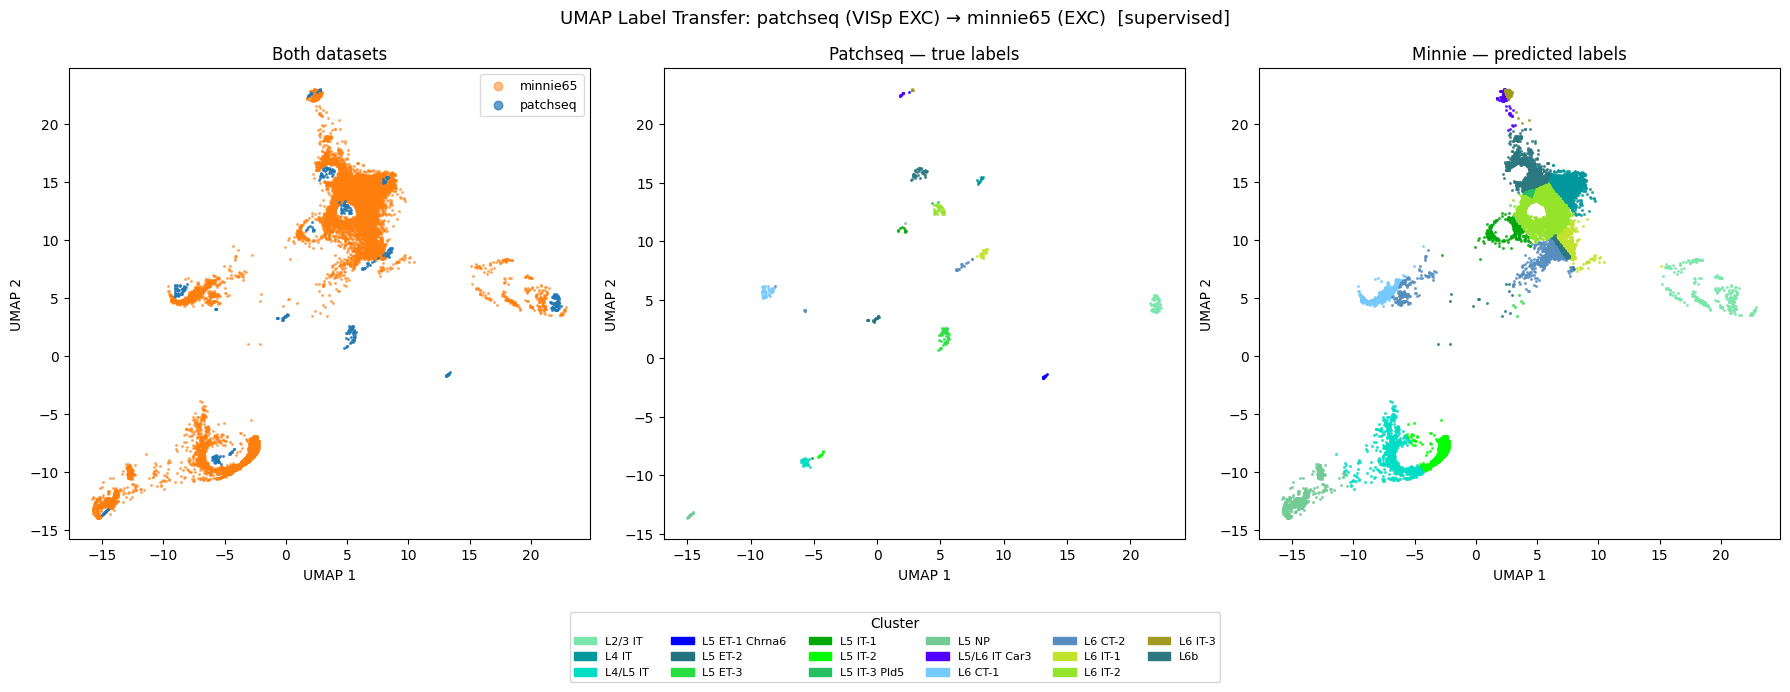

In [4]:
lt_exc_sup = UMAPLabelTransfer(DATA_ROOT, cell_type='exc')
lt_exc_sup.load_data()
lt_exc_sup.harmonize_features()
lt_exc_sup.save_harmonized_h5ad('/scratch/h5ad_outputs')  # optional
lt_exc_sup.scale(method='robust')
#lt_exc_sup.plot_alignment_diagnostics(top_n=5)
lt_exc_sup.fit_umap(mode='supervised')
lt_exc_sup.transfer_labels(k=3)
lt_exc_sup.plot_umap()

## INH · supervised UMAP

Patchseq features: (520, 49)
Unique patchseq cells: 495, unique labels: 28
Patchseq after label join: (495, 52)
Minnie features: (163, 54)
Shared features:  46
Only in patchseq: 2  → ['level', 'heirachy_category']
Only in minnie:   5  → ['basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_2']
Patchseq: 495 → 495 rows (dropped 0)
Minnie:   163 → 163 rows (dropped 0)
Saved patchseq h5ad → /scratch/h5ad_outputs/inh_patchseq_harmonized.h5ad  (495, 46)
Saved minnie h5ad  → /scratch/h5ad_outputs/inh_minnie_harmonized.h5ad  (163, 46)
Scaled patchseq (robust): (495, 46)
Scaled minnie   (robust): (163, 46)


/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Patchseq embedding (supervised): (495, 2)
Minnie embedding   (supervised): (163, 2)
Minnie predicted label counts:
  Vip-MET-5                                          55
  Sst-MET-9                                          31
  Pvalb-MET-5                                        19
  Sncg-MET-1                                         11
  Pvalb-MET-4                                        9
  Sst-MET-2                                          6
  Pvalb-MET-1                                        4
  Sst-MET-11                                         4
  Pvalb-MET-3                                        3
  Sst-MET-13                                         3
  Sst-MET-6                                          3
  Sst-MET-7                                          3
  Vip-MET-2                                          3
  Lamp5-MET-1                                        2
  Sst-MET-3                                          2
  Sst-MET-4                                          2
 

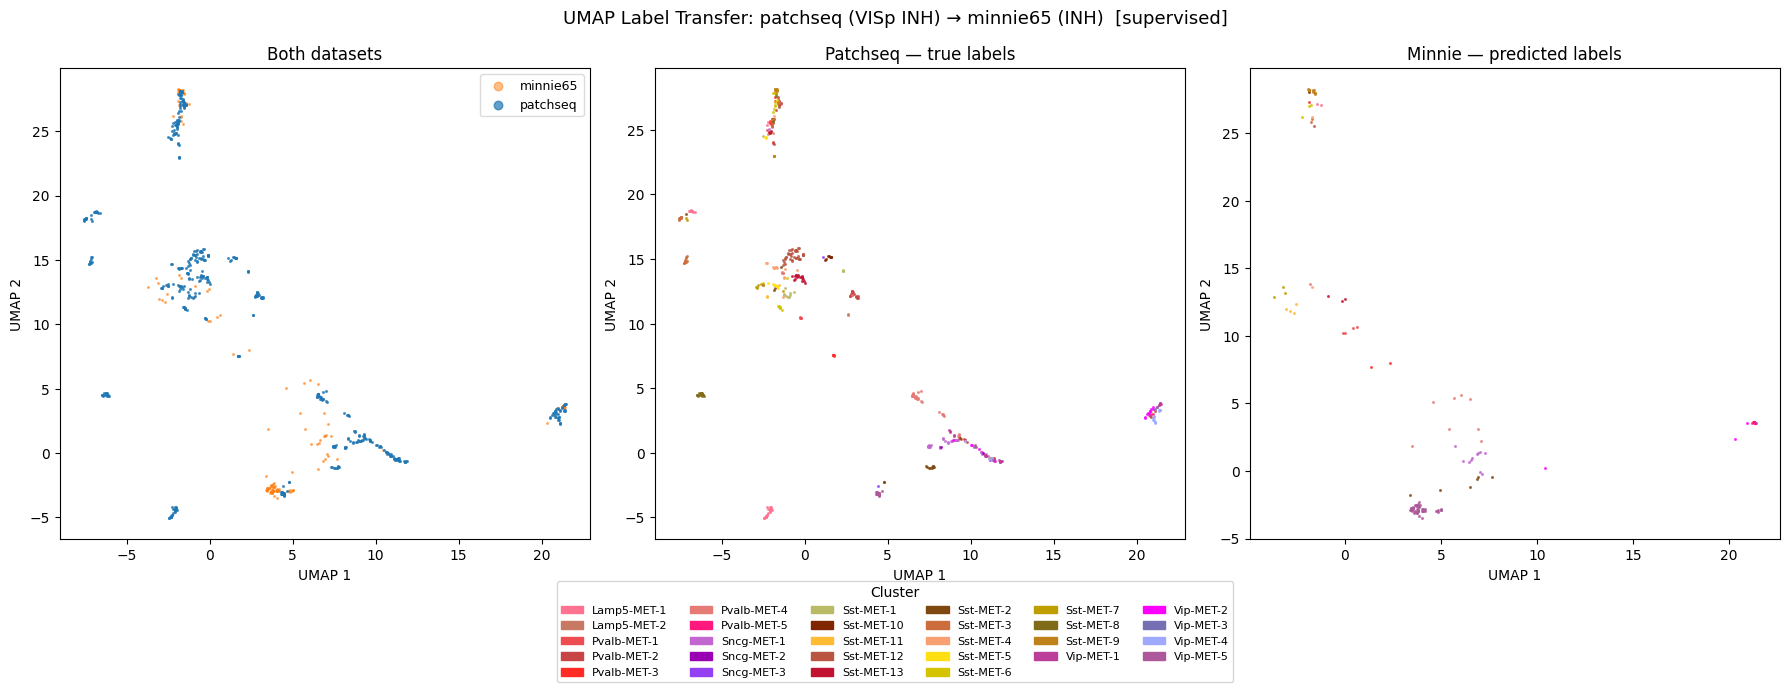

In [5]:
lt_inh_sup = UMAPLabelTransfer(DATA_ROOT, cell_type='inh')
lt_inh_sup.load_data()
lt_inh_sup.harmonize_features()
lt_inh_sup.save_harmonized_h5ad('/scratch/h5ad_outputs')  # optional
lt_inh_sup.scale(method='robust')
#lt_inh_sup.plot_alignment_diagnostics(top_n=5)
lt_inh_sup.fit_umap(mode='supervised')
lt_inh_sup.transfer_labels(k=3)
lt_inh_sup.plot_umap()

---

# Save predictions

In [33]:
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
pd_exc_mn = pd.DataFrame(
    {
        "id": lt_exc_sup._df_mn['id'].to_list(),
        "predicted_label": lt_exc_sup._mn_predicted
    }
)

pd_exc_mn.head()

,id,predicted_label
0,23141,L6b
1,23332,L6 IT-1
2,23373,L5 IT-2
3,23382,L6 IT-1
4,23385,L5 IT-2


In [16]:
pd_inh_mn = pd.DataFrame(
    {
        "id": lt_inh_sup._df_mn['id'].to_list(),
        "predicted_label": lt_inh_sup._mn_predicted
    }
)

pd_inh_mn.head()

,id,predicted_label
0,252232,Sst-MET-9
1,255120,Vip-MET-5
2,255129,Sst-MET-11
3,255137,Vip-MET-5
4,255208,Vip-MET-5


In [23]:
eilist = ['exc', 'inh']
eifiles = ['{}_minnie_met_umapknn.h5ad'.format(eilist[i]) for i in range(len(eilist))]
eidfs = [pd_exc_mn, pd_inh_mn]

In [25]:
for i in range(len(eilist)):
    curpath = os.path.join('/scratch/h5ad_outputs', eifiles[i])
    curdf = eidfs[i]
    adata = ad.AnnData(obs=curdf)
    adata.write_h5ad(curpath)

/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


,id,predicted_label
0,252232,Sst-MET-9
1,255120,Vip-MET-5
2,255129,Sst-MET-11
3,255137,Vip-MET-5
4,255208,Vip-MET-5
...,...,...
158,309481,Sncg-MET-1
159,309508,Vip-MET-1
160,309578,Pvalb-MET-5
161,342232,Pvalb-MET-3


/tmp/ipykernel_1363/2822669088.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1363/2822669088.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


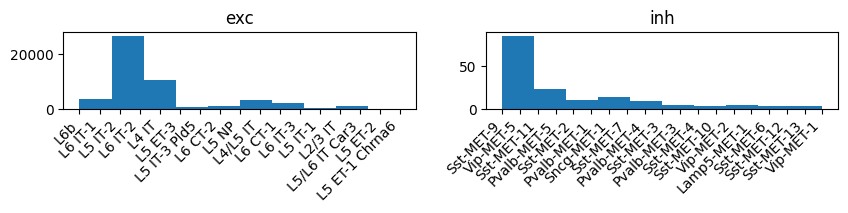

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=[10,1])

for i in range(len(eilist)):
    curpath = os.path.join('/scratch/h5ad_outputs', eifiles[i])
    adata = ad.read_h5ad(curpath)
    curdf = adata.obs
    ax = axes[i]
    ax. hist(curdf['predicted_label'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(eilist[i])